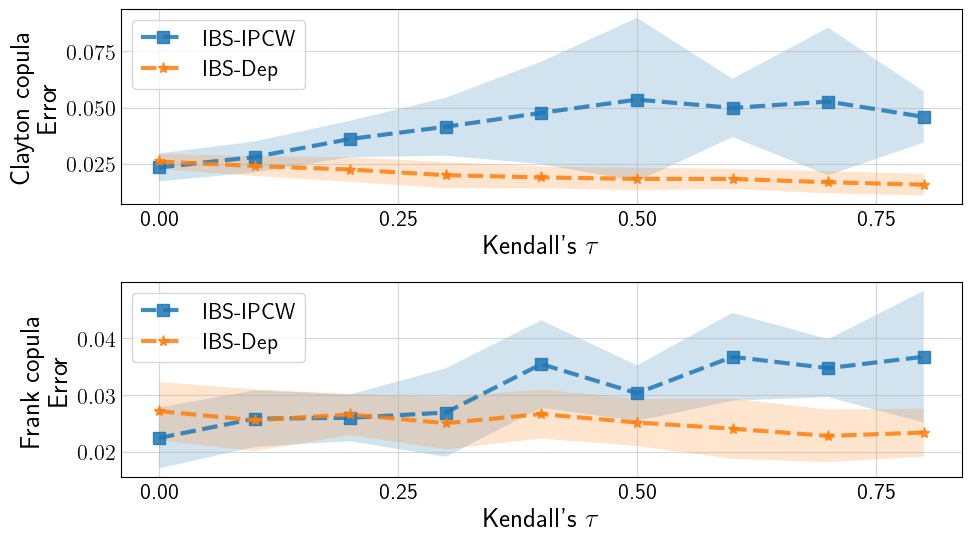

In [1]:
import numpy as np
import pandas as pd
import config as cfg
from matplotlib import pyplot as plt

plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "large",
    "font.size": 16.0,
    "legend.fontsize": "medium",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}"
})

filename = f"{cfg.RESULTS_DIR}/synthetic_results_correct_copula.csv"
df = pd.read_csv(filename)

# Columns expected in the file:
# copula_name, k_tau, err_ipcw, err_dep_bguw, (seed, censoring_rate, ...)
metric1, metric2 = "err_ipcw", "err_dep_bguw"
label1, label2 = "IBS-IPCW", r"IBS-Dep"

sigma_level = 1.0
copulas = ["clayton", "frank"]

# Aggregate across seeds (and any other repeated runs)
grouped = (
    df.groupby(["copula_name", "k_tau"])[[metric1, metric2]]
      .agg(["mean", "std"])
      .reset_index()
)
grouped.columns = ["_".join(c).rstrip("_") if isinstance(c, tuple) else c for c in grouped.columns]

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

for row_idx, copula in enumerate(copulas):
    ax = axes[row_idx]
    sub = grouped[grouped["copula_name"] == copula].sort_values("k_tau")

    x = sub["k_tau"].to_numpy()

    m1 = sub[f"{metric1}_mean"].to_numpy()
    s1 = sub[f"{metric1}_std"].to_numpy()

    m2 = sub[f"{metric2}_mean"].to_numpy()
    s2 = sub[f"{metric2}_std"].to_numpy()

    # Lines
    ax.plot(x, m1, linestyle="dashed", marker="s", markersize=8, linewidth=3, alpha=0.85, label=label1)
    ax.plot(x, m2, linestyle="dashed", marker="*", markersize=8, linewidth=3, alpha=0.85, label=label2)

    # Shaded ± SD (skip NaNs safely)
    if np.any(~np.isnan(s1)):
        ax.fill_between(x, m1 - sigma_level * s1, m1 + sigma_level * s1, alpha=0.2)
    if np.any(~np.isnan(s2)):
        ax.fill_between(x, m2 - sigma_level * s2, m2 + sigma_level * s2, alpha=0.2)

    ax.set_ylabel(f"{copula.capitalize()} copula\nError")
    ax.grid(True, alpha=0.5)
    ax.tick_params(axis="y", which="both", length=0)
    ax.tick_params(axis="x", which="both", length=0)
    ax.legend(loc="upper left")
    
    ax.set_xlabel(r"Kendall's $\tau$")
    ax.set_xticks([0.0, 0.25, 0.5, 0.75])
    ax.set_xticklabels(["0.00", "0.25", "0.50", "0.75"])

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f"{cfg.PLOTS_DIR}/synthetic_correct_copula.pdf", format="pdf", bbox_inches="tight")
plt.show()